# Toy-ParaRNN MVP: parity task через систему нелинейных уравнений

Цель ноутбука — показать на простой toy-RNN, что рекуррентное вычисление можно:

1. выполнить обычным последовательным проходом;
2. переписать как систему уравнений `F(h)=0`;
3. решить методом Ньютона;
4. на шаге Ньютона получить линейную рекурсию;
5. решить эту линейную рекурсию через toy parallel scan / doubling.

Это учебная демонстрация идеи, а не реализация настоящей Apple ParaRNN.


In [1]:
from pathlib import Path
import math
import time

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

ALPHA = 2.0
H0 = 1.0

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

## 1. Parity task и данные

В parity task входом является бинарная последовательность `x_t ∈ {0, 1}`.
Метка равна `0`, если число единиц чётное, и `1`, если число единиц нечётное.

Для toy-RNN удобно заменить вход на знак:

```text
s_t = 1 - 2x_t

x_t = 0 -> s_t = +1
x_t = 1 -> s_t = -1
```


In [2]:
def parity_label(x: np.ndarray) -> int:
    """
    Возвращает 0, если количество единиц в x чётное.
    Возвращает 1, если количество единиц в x нечётное.
    """
    return int(np.sum(x) % 2)


def generate_sequence(seq_len: int, seed: int | None = None) -> np.ndarray:
    """
    Генерирует одну бинарную последовательность длины seq_len.
    Возвращает numpy array формы (seq_len,).
    """
    if seed is not None:
        rng = np.random.default_rng(seed)
        return rng.integers(0, 2, size=seq_len, dtype=int)

    return np.random.randint(0, 2, size=seq_len)


def generate_batch(
    batch_size: int,
    seq_len: int,
    seed: int | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Генерирует batch бинарных последовательностей.

    Возвращает:
    X: shape (batch_size, seq_len)
    y: shape (batch_size,)
    """
    rng = np.random.default_rng(seed)
    X = rng.integers(0, 2, size=(batch_size, seq_len), dtype=int)
    y = np.array([parity_label(row) for row in X], dtype=int)
    return X, y


def s_from_x(x: np.ndarray) -> np.ndarray:
    """
    Преобразует x из {0, 1} в s из {+1, -1}.
    s = 1 - 2x
    """
    x = np.asarray(x, dtype=int)
    return 1 - 2 * x


In [3]:
assert parity_label(np.array([0, 0, 0])) == 0
assert parity_label(np.array([1, 0, 0])) == 1
assert parity_label(np.array([1, 1, 0])) == 0
assert np.array_equal(s_from_x(np.array([0, 1, 0, 1])), np.array([1, -1, 1, -1]))

X_check, y_check = generate_batch(batch_size=4, seq_len=6, seed=0)
assert X_check.shape == (4, 6)
assert y_check.shape == (4,)
assert all(y_check[i] == parity_label(X_check[i]) for i in range(len(y_check)))

print("Data helpers: OK")


Data helpers: OK


## 2. Обычная последовательная toy-RNN

Скрытое состояние кодирует чётность префикса знаком:

```text
h_t > 0 -> чётная чётность префикса
h_t < 0 -> нечётная чётность префикса
```

Начинаем с `h_0 = +1`. Рекуррентное правило:

```text
h_t = tanh(alpha * s_t * h_{t-1}), alpha = 2.0
```


In [4]:
def rnn_step(h_prev: float, x_t: int, alpha: float = ALPHA) -> float:
    """
    Один шаг toy-RNN:
    h_t = tanh(alpha * s_t * h_{t-1})
    """
    s_t = 1 - 2 * int(x_t)
    return float(np.tanh(alpha * s_t * h_prev))


def sequential_rnn(
    x: np.ndarray,
    alpha: float = ALPHA,
    h0: float = H0,
) -> np.ndarray:
    """
    Обычный последовательный проход toy-RNN.

    Вход:
    x: массив из 0 и 1 длины L.

    Выход:
    h: массив длины L+1:
       h[0] = h0
       h[1] = h_1
       ...
       h[L] = h_L
    """
    x = np.asarray(x)
    h = np.zeros(len(x) + 1)
    h[0] = h0

    for t in range(len(x)):
        h[t + 1] = rnn_step(h[t], x[t], alpha)

    return h


def predict_from_hidden(h_last: float) -> int:
    """
    Если h_last > 0, возвращает 0.
    Если h_last < 0, возвращает 1.
    """
    return int(h_last < 0)


In [5]:
examples = [
    np.array([0, 1, 0, 1]),
    np.array([1, 0, 1, 1]),
    np.array([0, 0, 0, 0]),
    np.array([1, 1, 1, 1]),
    np.array([1, 0, 0, 0]),
]

for x in examples:
    h = sequential_rnn(x)
    y_true = parity_label(x)
    y_pred = predict_from_hidden(h[-1])
    print("x =", x, "true =", y_true, "pred =", y_pred, "h_last =", h[-1])
    assert y_true == y_pred


x = [0 1 0 1] true = 0 pred = 0 h_last = 0.9575336226217068
x = [1 0 1 1] true = 1 pred = 1 h_last = -0.9575336226217068
x = [0 0 0 0] true = 0 pred = 0 h_last = 0.9575336226217068
x = [1 1 1 1] true = 0 pred = 0 h_last = 0.9575336226217068
x = [1 0 0 0] true = 1 pred = 1 h_last = -0.9575336226217068


## 3. Hidden state как память о префиксе

На каждом шаге знак `h_t` должен совпадать с parity уже прочитанного префикса.
Для `t=0` префикс пустой, поэтому parity равна `0`.


In [6]:
def prefix_parities(x: np.ndarray) -> np.ndarray:
    """
    Возвращает массив длины L+1.
    prefix_parities[t] = parity для префикса x[:t].
    Для t=0 parity равна 0, потому что единиц пока нет.
    """
    out = [0]
    current = 0

    for value in x:
        current = (current + int(value)) % 2
        out.append(current)

    return np.array(out)


x_demo = np.array([1, 0, 1, 1])
h_demo = sequential_rnn(x_demo)
p_demo = prefix_parities(x_demo)

for t in range(len(h_demo)):
    x_text = "-" if t == 0 else str(x_demo[t - 1])
    sign_text = "even" if h_demo[t] > 0 else "odd"
    print(
        f"t={t}, x={x_text}, h={h_demo[t]:+.4f}, "
        f"sign={sign_text}, prefix_parity={p_demo[t]}"
    )

assert len(p_demo) == len(h_demo)
assert all((h_demo[t] > 0) == (p_demo[t] == 0) for t in range(len(h_demo)))


t=0, x=-, h=+1.0000, sign=even, prefix_parity=0
t=1, x=1, h=-0.9640, sign=odd, prefix_parity=1
t=2, x=0, h=-0.9586, sign=odd, prefix_parity=1
t=3, x=1, h=+0.9577, sign=even, prefix_parity=0
t=4, x=1, h=-0.9575, sign=odd, prefix_parity=1


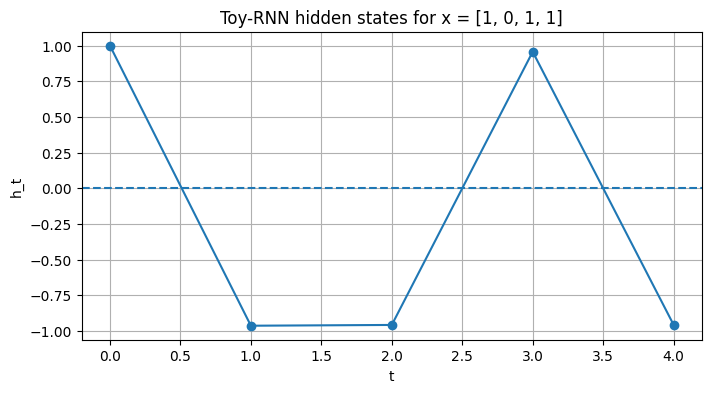

In [7]:
def plot_hidden_states(
    x: np.ndarray,
    h: np.ndarray,
    title: str = "Hidden states",
    save_path: Path | None = None,
) -> None:
    """
    Строит график h_t по времени.
    Также рисует горизонтальную линию y=0.
    """
    plt.figure(figsize=(8, 4))
    plt.plot(range(len(h)), h, marker="o")
    plt.axhline(0, linestyle="--")
    plt.xlabel("t")
    plt.ylabel("h_t")
    plt.title(title)
    plt.grid(True)

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


plot_hidden_states(
    x_demo,
    h_demo,
    title="Toy-RNN hidden states for x = [1, 0, 1, 1]",
    save_path=RESULTS_DIR / "hidden_states_example.png",
)

## 4. Переписываем RNN как систему уравнений `F(h)=0`

Обычная RNN задаёт уравнения:

```text
h_t = tanh(alpha * s_t * h_{t-1})
```

Переносим всё в левую часть:

```text
F_t(h) = h_t - tanh(alpha * s_t * h_{t-1}) = 0
```

Теперь неизвестными являются сразу все состояния:

```text
h = [h_1, h_2, ..., h_L]
```

Если `F(h)=0`, значит все рекуррентные правила выполнены одновременно.


In [8]:
def residual_F(
    h_unknown: np.ndarray,
    x: np.ndarray,
    alpha: float = ALPHA,
    h0: float = H0,
) -> np.ndarray:
    """
    Считает F(h) для системы уравнений toy-RNN.

    h_unknown: массив длины L, содержащий [h_1, ..., h_L]
    x: бинарная последовательность длины L

    Возвращает:
    F: массив длины L, где
       F[t] = h_t - tanh(alpha * s_t * h_{t-1})

    Важно:
    в коде индексация с нуля:
       h_unknown[0] соответствует h_1
       h_unknown[t] соответствует h_{t+1}
    """
    x = np.asarray(x)
    h_unknown = np.asarray(h_unknown)
    L = len(x)
    s = s_from_x(x)

    F = np.zeros(L)

    for t in range(L):
        h_t = h_unknown[t]
        if t == 0:
            h_prev = h0
        else:
            h_prev = h_unknown[t - 1]

        F[t] = h_t - np.tanh(alpha * s[t] * h_prev)

    return F


def residual_norm(
    h_unknown: np.ndarray,
    x: np.ndarray,
    alpha: float = ALPHA,
    h0: float = H0,
) -> float:
    """
    Возвращает ||F(h)||_2.
    """
    return float(np.linalg.norm(residual_F(h_unknown, x, alpha, h0)))


In [9]:
x = np.array([1, 0, 1, 1])
h_seq = sequential_rnn(x)

F_at_seq = residual_F(h_seq[1:], x)
print("F(h_seq) =", F_at_seq)
print("||F(h_seq)|| =", np.linalg.norm(F_at_seq))

assert np.linalg.norm(F_at_seq) < 1e-12


F(h_seq) = [0. 0. 0. 0.]
||F(h_seq)|| = 0.0


## 5. Якобиан и Newton step

Метод Ньютона решает систему `F(h)=0` итерациями.

На каждой итерации есть текущее приближение `h`.
Мы ищем поправку `delta`:

```text
h_new = h + delta
```

Поправка находится из линейной системы:

```text
J delta = -F(h)
```

`J` — это матрица производных. В нашем случае она простая:
каждое уравнение `F_t` зависит только от `h_t` и `h_{t-1}`.
Поэтому матрица почти пустая: на диагонали стоят `1`,
а под диагональю стоят коэффициенты, связанные с производной `tanh`.

У нас:

```text
F_t = h_t - tanh(alpha * s_t * h_{t-1})
```

Производная по предыдущему состоянию:

```text
d/dh_{t-1} tanh(alpha * s_t * h_{t-1})
= alpha * s_t * (1 - tanh(alpha * s_t * h_{t-1})^2)
```

Обозначим:

```text
a_t = alpha * s_t * (1 - tanh(alpha * s_t * h_{t-1})^2)
```

Тогда Newton step превращается в линейную рекурсию:

```text
delta_t = a_t * delta_{t-1} + b_t
```

где:

```text
b_t = -F_t
```

В коде индексация с нуля:

```text
delta[i] соответствует поправке для h_{i+1}
```

Для первого уравнения `h_0` фиксирован, поэтому:

```text
a[0] = 0
```


In [10]:
def jacobian_coefficients(
    h_unknown: np.ndarray,
    x: np.ndarray,
    alpha: float = ALPHA,
    h0: float = H0,
) -> np.ndarray:
    """
    Возвращает массив a длины L для линейной рекурсии Newton step:

        delta[i] = a[i] * delta[i-1] + b[i]

    Для i=0:
        a[0] = 0

    Для i>=1:
        a[i] = alpha * s[i] * (1 - tanh(alpha * s[i] * h_unknown[i-1])**2)
    """
    x = np.asarray(x)
    h_unknown = np.asarray(h_unknown)
    L = len(x)
    s = s_from_x(x)

    a = np.zeros(L)

    for i in range(1, L):
        z = alpha * s[i] * h_unknown[i - 1]
        a[i] = alpha * s[i] * (1.0 - np.tanh(z) ** 2)

    return a


def build_dense_jacobian(a: np.ndarray) -> np.ndarray:
    """
    Строит плотную матрицу J размера L x L.

    На диагонали стоят 1.
    Под диагональю стоят -a[i].

    J delta = -F
    """
    a = np.asarray(a)
    L = len(a)
    J = np.eye(L)

    for i in range(1, L):
        J[i, i - 1] = -a[i]

    return J


## 6. Решение линейной рекурсии для Newton step

Сначала реализуем обычное последовательное решение:

```text
delta[i] = a[i] * delta[i-1] + b[i]
```

Считаем, что `delta[-1] = 0`, поэтому `delta[0] = b[0]`.


In [11]:
def solve_linear_recurrence_sequential(
    a: np.ndarray,
    b: np.ndarray,
) -> np.ndarray:
    """
    Решает линейную рекурсию:

        delta[i] = a[i] * delta[i-1] + b[i]

    Считаем, что delta[-1] = 0.
    Поэтому для i=0:
        delta[0] = b[0]
    """
    a = np.asarray(a)
    b = np.asarray(b)
    L = len(a)

    delta = np.zeros(L)
    prev = 0.0

    for i in range(L):
        delta[i] = a[i] * prev + b[i]
        prev = delta[i]

    return delta


## 7. Toy parallel scan / doubling

Линейную рекурсию можно представить как последовательность преобразований:

```text
T_i(z) = a_i * z + b_i
```

Тогда:

```text
delta_0 = T_0(0)
delta_1 = T_1(T_0(0))
delta_2 = T_2(T_1(T_0(0)))
```

Нужно посчитать префиксные композиции преобразований.

Композиция двух преобразований снова имеет такой же вид:

```text
если
T_left(z) = a1 * z + b1
T_right(z) = a2 * z + b2

то
T_right(T_left(z)) = (a2*a1) * z + (a2*b1 + b2)
```


In [12]:
def compose_affine(
    pair_right: tuple[float, float],
    pair_left: tuple[float, float],
) -> tuple[float, float]:
    """
    Композиция двух affine-преобразований.

    pair_left = (a1, b1), задаёт T_left(z) = a1*z + b1
    pair_right = (a2, b2), задаёт T_right(z) = a2*z + b2

    Возвращает параметры T_right(T_left(z)).
    """
    a2, b2 = pair_right
    a1, b1 = pair_left
    return a2 * a1, a2 * b1 + b2


def solve_linear_recurrence_scan(
    a: np.ndarray,
    b: np.ndarray,
) -> np.ndarray:
    """
    Демонстрационное решение рекурсии:

        delta[i] = a[i] * delta[i-1] + b[i]

    через идею parallel prefix / doubling.

    Важно:
    это не настоящая параллельная CUDA-реализация.
    На CPU это может быть медленнее обычного цикла.
    Цель — показать идею уменьшения глубины зависимостей.
    """
    a = np.asarray(a).copy()
    b = np.asarray(b).copy()
    L = len(a)

    A = a.copy()
    B = b.copy()

    step = 1
    while step < L:
        A_old = A.copy()
        B_old = B.copy()

        for i in range(step, L):
            # Compose current prefix transform with the prefix step positions before it.
            A[i] = A_old[i] * A_old[i - step]
            B[i] = A_old[i] * B_old[i - step] + B_old[i]

        step *= 2

    # delta[-1] = 0, therefore the result is B.
    return B


In [13]:
assert compose_affine((3.0, 4.0), (2.0, 1.0)) == (6.0, 7.0)

x_test = generate_sequence(seq_len=8, seed=1)
h_current = np.random.randn(len(x_test)) * 0.1

F = residual_F(h_current, x_test)
a = jacobian_coefficients(h_current, x_test)
b = -F

delta_seq = solve_linear_recurrence_sequential(a, b)
delta_scan = solve_linear_recurrence_scan(a, b)

J = build_dense_jacobian(a)
delta_dense = np.linalg.solve(J, b)

print("max |seq - scan| =", np.max(np.abs(delta_seq - delta_scan)))
print("max |seq - dense| =", np.max(np.abs(delta_seq - delta_dense)))

assert np.max(np.abs(delta_seq - delta_scan)) < 1e-10
assert np.max(np.abs(delta_seq - delta_dense)) < 1e-10


max |seq - scan| = 7.105427357601002e-15
max |seq - dense| = 5.684341886080802e-14


## 8. Newton solver

Для устойчивого MVP мы используем два варианта начального приближения:

- `zeros`: все неизвестные hidden states начинаются с нуля;
- `sign`: задаём правильный знак состояния, но не точное значение `h_t`.

Важный честный момент про `sign initialization`:

```text
signs = h0 * cumprod(s)
```

Здесь `s_t = +1`, если входной бит равен `0`, и `s_t = -1`, если входной бит равен `1`. Поэтому произведение `s_1 * ... * s_t` меняет знак ровно тогда, когда во входе встретилась единица. Это произведение уже кодирует parity префикса.

Значит, `sign initialization` не является честным способом предсказать parity: она уже использует структуру задачи и заранее ставит правильные знаки hidden states. Мы используем её только как устойчивое начальное приближение, чтобы удобно показать работу Newton solver.

Чтобы проверить, что Newton solver не полностью зависит от этого почти готового старта, ниже отдельно проверяется старт из нулей. Это важно для учебной демонстрации: студент должен видеть, где в эксперименте есть подсказка, а где solver действительно исправляет начальное приближение.

In [14]:
def initial_guess(
    x: np.ndarray,
    mode: str = "sign",
    magnitude: float = 0.9,
    h0: float = H0,
) -> np.ndarray:
    """
    Возвращает начальное приближение для [h_1, ..., h_L].

    mode="zeros":
        все нули.

    mode="sign":
        используем правильный знак parity-префикса, но не точную величину.
        h_init[t] = magnitude * h0 * cumulative_product(s[:t+1])

    Для MVP mode="sign" используется как стабильный старт для Newton,
    особенно на длинных последовательностях.
    """
    x = np.asarray(x)
    L = len(x)

    if mode == "zeros":
        return np.zeros(L)

    if mode == "sign":
        s = s_from_x(x)
        signs = h0 * np.cumprod(s)
        return magnitude * signs

    raise ValueError(f"Unknown init mode: {mode}")


def newton_solver(
    x: np.ndarray,
    alpha: float = ALPHA,
    h0: float = H0,
    max_iter: int = 20,
    tol: float = 1e-10,
    init_mode: str = "sign",
    init_magnitude: float = 0.9,
    linear_solver: str = "sequential",
    damping: float = 1.0,
    verbose: bool = False,
) -> tuple[np.ndarray, list[float]]:
    """
    Решает систему F(h)=0 методом Ньютона.

    Возвращает:
    h_unknown: найденные состояния [h_1, ..., h_L]
    history: список значений ||F(h)|| на каждой итерации
    """
    h = initial_guess(x, mode=init_mode, magnitude=init_magnitude, h0=h0)
    history = []

    for k in range(max_iter):
        F = residual_F(h, x, alpha=alpha, h0=h0)
        norm = np.linalg.norm(F)
        history.append(float(norm))

        if verbose:
            print(f"iter={k}, residual={norm:.3e}")

        if norm < tol:
            break

        a = jacobian_coefficients(h, x, alpha=alpha, h0=h0)
        b = -F

        if linear_solver == "sequential":
            delta = solve_linear_recurrence_sequential(a, b)
        elif linear_solver == "scan":
            delta = solve_linear_recurrence_scan(a, b)
        else:
            raise ValueError(f"Unknown linear_solver: {linear_solver}")

        h = h + damping * delta

    return h, history

In [15]:
x = generate_sequence(seq_len=32, seed=123)

h_seq_full = sequential_rnn(x)
h_seq = h_seq_full[1:]

h_newton_seq, hist_seq = newton_solver(
    x,
    init_mode="sign",
    linear_solver="sequential",
    verbose=True,
)

h_newton_scan, hist_scan = newton_solver(
    x,
    init_mode="sign",
    linear_solver="scan",
    verbose=True,
)

print("Sequential RNN final h:", h_seq[-1])
print("Newton sequential final h:", h_newton_seq[-1])
print("Newton scan final h:", h_newton_scan[-1])

print("max |RNN - Newton sequential| =", np.max(np.abs(h_seq - h_newton_seq)))
print("max |RNN - Newton scan| =", np.max(np.abs(h_seq - h_newton_scan)))
print("max |Newton seq - Newton scan| =", np.max(np.abs(h_newton_seq - h_newton_scan)))

assert np.max(np.abs(h_seq - h_newton_seq)) < 1e-8
assert np.max(np.abs(h_seq - h_newton_scan)) < 1e-8
assert np.max(np.abs(h_newton_seq - h_newton_scan)) < 1e-10

y_true = parity_label(x)
y_rnn = predict_from_hidden(h_seq[-1])
y_newton = predict_from_hidden(h_newton_seq[-1])
y_scan = predict_from_hidden(h_newton_scan[-1])

print("true:", y_true)
print("rnn:", y_rnn)
print("newton:", y_newton)
print("newton+scan:", y_scan)

assert y_true == y_rnn == y_newton == y_scan


iter=0, residual=2.684e-01
iter=1, residual=7.151e-03
iter=2, residual=4.061e-06
iter=3, residual=1.344e-12
iter=0, residual=2.684e-01
iter=1, residual=7.151e-03
iter=2, residual=4.061e-06
iter=3, residual=1.344e-12
Sequential RNN final h: 0.9575040240772688
Newton sequential final h: 0.9575040240775707
Newton scan final h: 0.9575040240775707
max |RNN - Newton sequential| = 3.0675462170393075e-13
max |RNN - Newton scan| = 3.0675462170393075e-13
max |Newton seq - Newton scan| = 0.0
true: 0
rnn: 0
newton: 0
newton+scan: 0


## 9. График сходимости Ньютона

Сравним норму residual для двух вариантов решения линейной рекурсии:
обычный последовательный solve и toy scan/doubling.


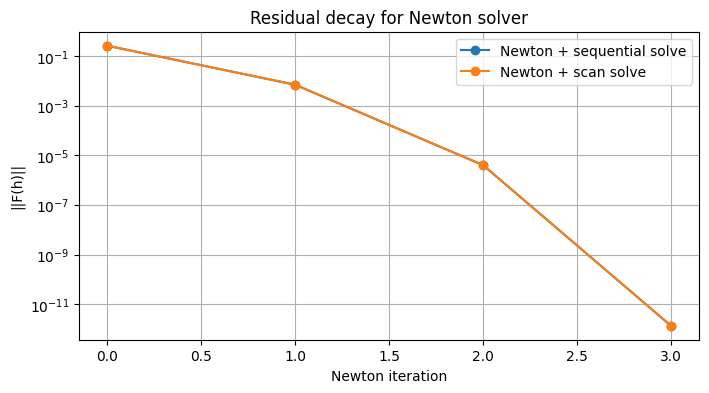

In [16]:
def plot_residual_history(
    histories: dict,
    title: str = "Newton residual norm",
    save_path: Path | None = None,
) -> None:
    """
    histories: dict name -> list of residual norms
    """
    plt.figure(figsize=(8, 4))

    for name, history in histories.items():
        values = np.maximum(np.asarray(history, dtype=float), 1e-16)
        plt.plot(range(len(values)), values, marker="o", label=name)

    plt.yscale("log")
    plt.xlabel("Newton iteration")
    plt.ylabel("||F(h)||")
    plt.title(title)
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


plot_residual_history(
    {
        "Newton + sequential solve": hist_seq,
        "Newton + scan solve": hist_scan,
    },
    title="Residual decay for Newton solver",
    save_path=RESULTS_DIR / "residual_decay.png",
)

## 10. Batch accuracy: sign initialization и zero initialization

Проверим accuracy на 100 случайных примерах длины 64 для трёх методов:

1. обычная sequential RNN;
2. Newton + sequential linear solve;
3. Newton + scan linear solve.

Сначала используем `sign initialization`, а затем честнее проверяем `zero initialization`. Для `alpha=2.0` оба варианта должны дать accuracy `1.0`.

In [17]:
def evaluate_methods(
    num_examples: int = 100,
    seq_len: int = 32,
    seed: int = 0,
    alpha: float = ALPHA,
    init_mode: str = "sign",
    max_iter: int = 20,
    tol: float = 1e-10,
    damping: float = 1.0,
) -> dict[str, float]:
    """
    Генерирует num_examples последовательностей.
    Сравнивает accuracy для:
    1. sequential RNN
    2. Newton + sequential linear solve
    3. Newton + scan linear solve

    Возвращает словарь с accuracy.
    """
    X, y = generate_batch(num_examples, seq_len, seed=seed)

    correct_rnn = 0
    correct_newton_seq = 0
    correct_newton_scan = 0

    for i in range(num_examples):
        x = X[i]
        true = y[i]

        h_rnn = sequential_rnn(x, alpha=alpha)
        pred_rnn = predict_from_hidden(h_rnn[-1])

        h_nseq, _ = newton_solver(
            x,
            alpha=alpha,
            linear_solver="sequential",
            init_mode=init_mode,
            max_iter=max_iter,
            tol=tol,
            damping=damping,
        )
        pred_nseq = predict_from_hidden(h_nseq[-1])

        h_nscan, _ = newton_solver(
            x,
            alpha=alpha,
            linear_solver="scan",
            init_mode=init_mode,
            max_iter=max_iter,
            tol=tol,
            damping=damping,
        )
        pred_nscan = predict_from_hidden(h_nscan[-1])

        correct_rnn += int(pred_rnn == true)
        correct_newton_seq += int(pred_nseq == true)
        correct_newton_scan += int(pred_nscan == true)

    return {
        "sequential_rnn": correct_rnn / num_examples,
        "newton_sequential_solve": correct_newton_seq / num_examples,
        "newton_scan_solve": correct_newton_scan / num_examples,
    }


acc_sign = evaluate_methods(
    num_examples=100,
    seq_len=64,
    seed=42,
    alpha=ALPHA,
    init_mode="sign",
    max_iter=20,
)
print("sign init:", acc_sign)

assert acc_sign["sequential_rnn"] == 1.0
assert acc_sign["newton_sequential_solve"] == 1.0
assert acc_sign["newton_scan_solve"] == 1.0

acc_zero = evaluate_methods(
    num_examples=100,
    seq_len=64,
    seed=42,
    alpha=ALPHA,
    init_mode="zeros",
    max_iter=50,
)
print("zero init:", acc_zero)

assert acc_zero["sequential_rnn"] == 1.0
assert acc_zero["newton_sequential_solve"] == 1.0
assert acc_zero["newton_scan_solve"] == 1.0

sign init: {'sequential_rnn': 1.0, 'newton_sequential_solve': 1.0, 'newton_scan_solve': 1.0}


zero init: {'sequential_rnn': 1.0, 'newton_sequential_solve': 1.0, 'newton_scan_solve': 1.0}


## 11. Dependency depth: `L` против `log2(L)`

Обычная RNN имеет цепочку зависимостей длины `L`.
Toy scan / doubling имеет примерно `log2(L)` уровней объединения.

Это не значит, что Python-код будет быстрее.
Это значит, что теоретическая глубина последовательных зависимостей меньше.


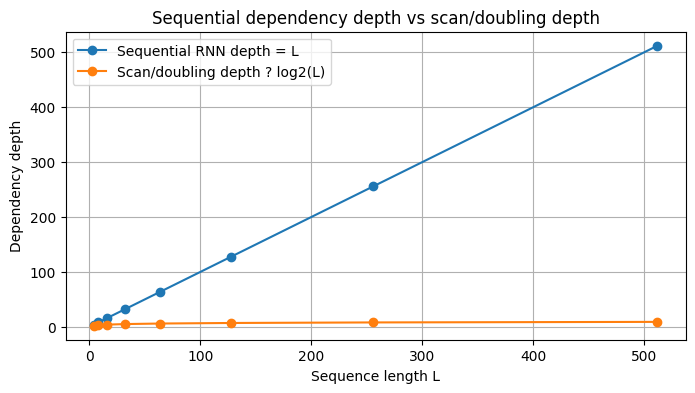

In [18]:
def plot_dependency_depth(lengths: list[int], save_path: Path | None = None) -> None:
    rnn_depth = np.array(lengths)
    scan_depth = np.array([math.ceil(math.log2(L)) if L > 1 else 1 for L in lengths])

    plt.figure(figsize=(8, 4))
    plt.plot(lengths, rnn_depth, marker="o", label="Sequential RNN depth = L")
    plt.plot(lengths, scan_depth, marker="o", label="Scan/doubling depth ? log2(L)")
    plt.xlabel("Sequence length L")
    plt.ylabel("Dependency depth")
    plt.title("Sequential dependency depth vs scan/doubling depth")
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


lengths = [4, 8, 16, 32, 64, 128, 256, 512]
plot_dependency_depth(lengths, save_path=RESULTS_DIR / "dependency_depth.png")

## 12. Мини-бенчмарк времени на CPU

Цель бенчмарка — не доказать ускорение, а честно показать время выполнения в Python на CPU.


L=   8 | RNN=0.000007s | NewtonSeq=0.000149s | NewtonScan=0.000149s
L=  16 | RNN=0.000009s | NewtonSeq=0.000248s | NewtonScan=0.000332s
L=  32 | RNN=0.000014s | NewtonSeq=0.000447s | NewtonScan=0.000571s
L=  64 | RNN=0.000026s | NewtonSeq=0.000869s | NewtonScan=0.001229s
L= 128 | RNN=0.000061s | NewtonSeq=0.001729s | NewtonScan=0.002450s
L= 256 | RNN=0.000099s | NewtonSeq=0.003539s | NewtonScan=0.004950s


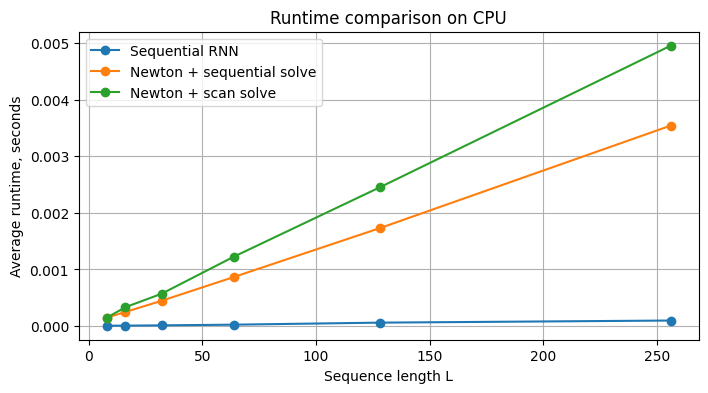

In [19]:
def time_function(fn, repeats: int = 5) -> float:
    """
    Возвращает среднее время выполнения fn() по repeats запускам.
    """
    times = []

    for _ in range(repeats):
        start = time.perf_counter()
        fn()
        end = time.perf_counter()
        times.append(end - start)

    return float(np.mean(times))


def benchmark_methods(
    lengths: list[int],
    repeats: int = 3,
    seed: int = 0,
    alpha: float = ALPHA,
) -> dict:
    """
    Для каждой длины L сравнивает время:
    1. sequential_rnn
    2. newton_solver with sequential linear solve
    3. newton_solver with scan linear solve

    Возвращает словарь результатов.
    """
    results = {
        "L": [],
        "sequential_rnn": [],
        "newton_seq": [],
        "newton_scan": [],
    }

    for L in lengths:
        x = generate_sequence(L, seed=seed + L)

        t_rnn = time_function(lambda: sequential_rnn(x, alpha=alpha), repeats=repeats)

        t_newton_seq = time_function(
            lambda: newton_solver(
                x,
                alpha=alpha,
                init_mode="sign",
                linear_solver="sequential",
                max_iter=20,
                tol=1e-10,
            ),
            repeats=repeats,
        )

        t_newton_scan = time_function(
            lambda: newton_solver(
                x,
                alpha=alpha,
                init_mode="sign",
                linear_solver="scan",
                max_iter=20,
                tol=1e-10,
            ),
            repeats=repeats,
        )

        results["L"].append(L)
        results["sequential_rnn"].append(t_rnn)
        results["newton_seq"].append(t_newton_seq)
        results["newton_scan"].append(t_newton_scan)

        print(
            f"L={L:4d} | "
            f"RNN={t_rnn:.6f}s | "
            f"NewtonSeq={t_newton_seq:.6f}s | "
            f"NewtonScan={t_newton_scan:.6f}s"
        )

    return results


def plot_benchmark_results(results: dict, save_path: Path | None = None) -> None:
    L = results["L"]

    plt.figure(figsize=(8, 4))
    plt.plot(L, results["sequential_rnn"], marker="o", label="Sequential RNN")
    plt.plot(L, results["newton_seq"], marker="o", label="Newton + sequential solve")
    plt.plot(L, results["newton_scan"], marker="o", label="Newton + scan solve")
    plt.xlabel("Sequence length L")
    plt.ylabel("Average runtime, seconds")
    plt.title("Runtime comparison on CPU")
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


lengths_bench = [8, 16, 32, 64, 128, 256]
bench_results = benchmark_methods(lengths_bench, repeats=3, seed=123)
plot_benchmark_results(bench_results, save_path=RESULTS_DIR / "runtime_vs_length.png")

На обычном CPU и в Python toy scan не обязан быть быстрее обычной RNN. Это нормально: наша цель — показать структуру вычислений и идею уменьшения глубины зависимостей, а не получить реальное ускорение.

Настоящее ускорение требует эффективной параллельной реализации, например на GPU.

## 13. Дополнительный локальный эксперимент: Newton из нулей

Ниже оставлен короткий пример для `L=16`, где на одном графике видно residual history для старта из нулей и для `sign initialization`.

iter=0, residual=9.640e-01
iter=1, residual=3.647e+04
iter=2, residual=1.353e-01
iter=3, residual=1.796e-03
iter=4, residual=3.855e-07
iter=5, residual=1.883e-14
iter=0, residual=1.923e-01
iter=1, residual=5.013e-03
iter=2, residual=2.777e-06
iter=3, residual=8.906e-13


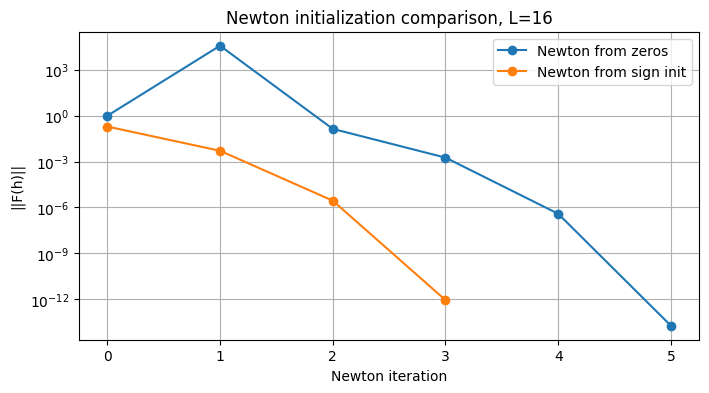

In [20]:
x_small = generate_sequence(seq_len=16, seed=7)

h_zero_init, hist_zero = newton_solver(
    x_small,
    init_mode="zeros",
    linear_solver="sequential",
    max_iter=20,
    tol=1e-10,
    verbose=True,
)

h_sign_init, hist_sign = newton_solver(
    x_small,
    init_mode="sign",
    linear_solver="sequential",
    max_iter=20,
    tol=1e-10,
    verbose=True,
)

plot_residual_history(
    {
        "Newton from zeros": hist_zero,
        "Newton from sign init": hist_sign,
    },
    title="Newton initialization comparison, L=16",
)

h_small_seq = sequential_rnn(x_small)[1:]
assert np.max(np.abs(h_zero_init - h_small_seq)) < 1e-8
assert np.max(np.abs(h_sign_init - h_small_seq)) < 1e-8


На этом коротком примере старт из нулей приходит к тем же hidden states, что и обычная sequential RNN. Это не отменяет честного замечания выше: `sign initialization` использует структуру parity и нужен только как стабильный старт для демонстрации Newton solver.

## 14. Ошибка Newton относительно sequential RNN

Теперь сравним найденные Newton solver скрытые состояния с обычным последовательным проходом RNN для разных длин последовательности.

Измеряем:

```text
max |h_newton - h_sequential|
```

L=  8 | seq error=3.068e-13 | scan error=3.068e-13
L= 16 | seq error=3.068e-13 | scan error=3.068e-13
L= 32 | seq error=3.068e-13 | scan error=3.068e-13
L= 64 | seq error=3.068e-13 | scan error=3.068e-13
L=128 | seq error=3.068e-13 | scan error=3.068e-13
L=256 | seq error=3.068e-13 | scan error=3.068e-13


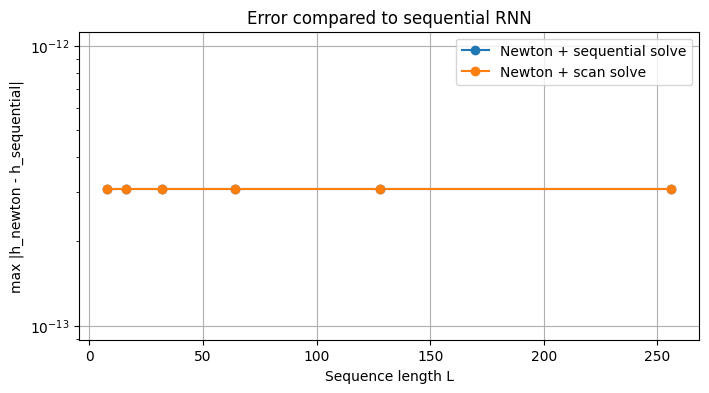

In [21]:
def plot_newton_error_vs_length(
    lengths: list[int],
    errors_seq: list[float],
    errors_scan: list[float],
    save_path: Path | None = None,
) -> None:
    values_seq = np.maximum(np.asarray(errors_seq, dtype=float), 1e-16)
    values_scan = np.maximum(np.asarray(errors_scan, dtype=float), 1e-16)

    plt.figure(figsize=(8, 4))
    plt.plot(lengths, values_seq, marker="o", label="Newton + sequential solve")
    plt.plot(lengths, values_scan, marker="o", label="Newton + scan solve")
    plt.yscale("log")
    plt.xlabel("Sequence length L")
    plt.ylabel("max |h_newton - h_sequential|")
    plt.title("Error compared to sequential RNN")
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


lengths_error = [8, 16, 32, 64, 128, 256]
errors_seq = []
errors_scan = []

for L in lengths_error:
    x = generate_sequence(L, seed=100 + L)
    h_ref = sequential_rnn(x, alpha=ALPHA)[1:]

    h_nseq, _ = newton_solver(
        x,
        alpha=ALPHA,
        linear_solver="sequential",
        init_mode="sign",
        max_iter=20,
    )

    h_nscan, _ = newton_solver(
        x,
        alpha=ALPHA,
        linear_solver="scan",
        init_mode="sign",
        max_iter=20,
    )

    err_seq = float(np.max(np.abs(h_nseq - h_ref)))
    err_scan = float(np.max(np.abs(h_nscan - h_ref)))
    errors_seq.append(err_seq)
    errors_scan.append(err_scan)

    print(f"L={L:3d} | seq error={err_seq:.3e} | scan error={err_scan:.3e}")

    assert err_seq < 1e-8
    assert err_scan < 1e-8

plot_newton_error_vs_length(
    lengths_error,
    errors_seq,
    errors_scan,
    save_path=RESULTS_DIR / "newton_error_vs_length.png",
)

## 15. Эксперимент: влияние alpha

Параметр `alpha` управляет силой нелинейного перехода:

```text
h_t = tanh(alpha * s_t * h_{t-1})
```

Если `alpha` маленькое, `tanh` слабее, и `|h_t|` может постепенно становиться очень маленьким. Знак математически сохраняет parity, но численно состояние становится менее уверенным.

Если `alpha` около `2`, hidden state обычно хорошо держит знак и величину.

Если `alpha` большое, `tanh` быстро насыщается около `+1` или `-1`. Это даёт уверенный знак, но производные `tanh` становятся маленькими в насыщении, что может влиять на численное поведение Newton solver.

Здесь мы не обучаем `alpha`. Мы просто смотрим, как выбранный параметр влияет на toy-систему.

alpha | acc_rnn | acc_newton_seq_zero | acc_newton_scan_zero | acc_newton_seq_sign | acc_newton_scan_sign | mean_abs_h_last | min_abs_h_last | mean_iter_zero
-------------------------------------------------------------------------------------------------------------------------------------------------------------
  0.5 | 1.00 | 1.00 | 1.00 | 1.00 | 1.00 | 4.895e-20 | 4.895e-20 | 4.0
  1.0 | 1.00 | 1.00 | 1.00 | 1.00 | 1.00 | 1.507e-01 | 1.507e-01 | 8.0
  2.0 | 1.00 | 1.00 | 1.00 | 1.00 | 1.00 | 9.575e-01 | 9.575e-01 | 8.0
  5.0 | 1.00 | 1.00 | 1.00 | 1.00 | 1.00 | 9.999e-01 | 9.999e-01 | 9.0
 10.0 | 1.00 | 1.00 | 1.00 | 1.00 | 1.00 | 1.000e+00 | 1.000e+00 | 10.0


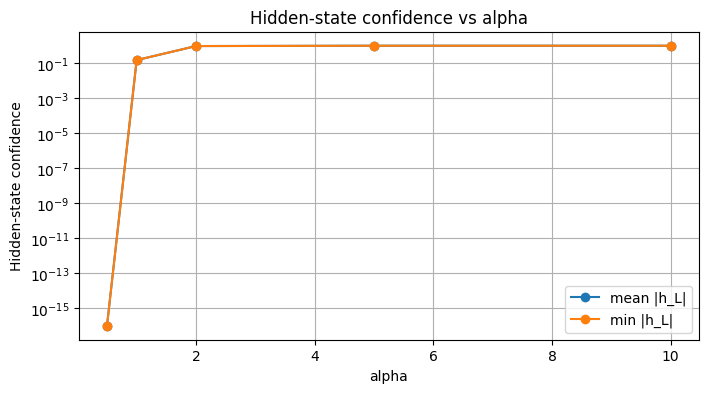

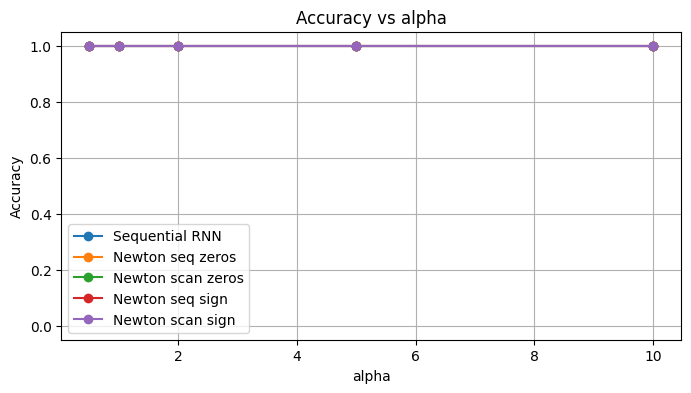

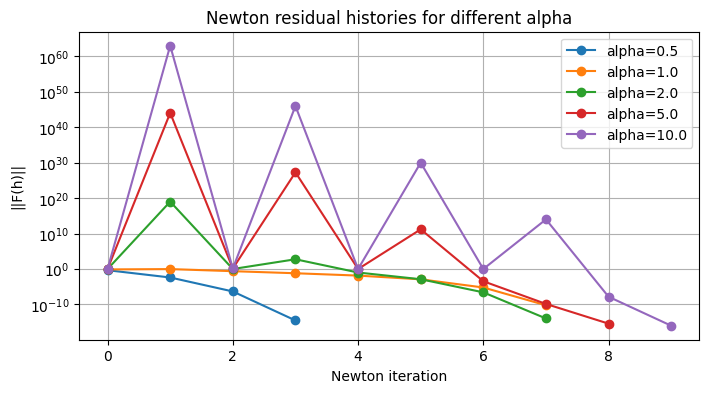

In [22]:
def run_alpha_experiment(
    alphas: list[float],
    num_examples: int = 50,
    seq_len: int = 64,
    seed: int = 2024,
) -> list[dict[str, float]]:
    """
    Для каждого alpha считает:
    - accuracy sequential RNN;
    - accuracy Newton + sequential solve, init=zeros;
    - accuracy Newton + scan solve, init=zeros;
    - accuracy Newton + sequential solve, init=sign;
    - accuracy Newton + scan solve, init=sign;
    - mean_abs_h_last для sequential RNN;
    - min_abs_h_last для sequential RNN;
    - mean final residual для Newton zeros sequential;
    - mean number of Newton iterations for zeros sequential.
    """
    rows = []

    for alpha in alphas:
        X, y = generate_batch(num_examples, seq_len, seed=seed)

        correct_rnn = 0
        correct_newton_seq_zero = 0
        correct_newton_scan_zero = 0
        correct_newton_seq_sign = 0
        correct_newton_scan_sign = 0
        abs_h_last_values = []
        final_residuals_zero = []
        iterations_zero = []

        for i in range(num_examples):
            x = X[i]
            true = y[i]

            h_rnn = sequential_rnn(x, alpha=alpha)
            abs_h_last_values.append(abs(float(h_rnn[-1])))
            correct_rnn += int(predict_from_hidden(h_rnn[-1]) == true)

            h_seq_zero, hist_seq_zero = newton_solver(
                x,
                alpha=alpha,
                init_mode="zeros",
                linear_solver="sequential",
                max_iter=50,
                tol=1e-10,
            )
            correct_newton_seq_zero += int(predict_from_hidden(h_seq_zero[-1]) == true)
            final_residuals_zero.append(hist_seq_zero[-1])
            iterations_zero.append(len(hist_seq_zero))

            h_scan_zero, _ = newton_solver(
                x,
                alpha=alpha,
                init_mode="zeros",
                linear_solver="scan",
                max_iter=50,
                tol=1e-10,
            )
            correct_newton_scan_zero += int(predict_from_hidden(h_scan_zero[-1]) == true)

            h_seq_sign, _ = newton_solver(
                x,
                alpha=alpha,
                init_mode="sign",
                linear_solver="sequential",
                max_iter=20,
                tol=1e-10,
            )
            correct_newton_seq_sign += int(predict_from_hidden(h_seq_sign[-1]) == true)

            h_scan_sign, _ = newton_solver(
                x,
                alpha=alpha,
                init_mode="sign",
                linear_solver="scan",
                max_iter=20,
                tol=1e-10,
            )
            correct_newton_scan_sign += int(predict_from_hidden(h_scan_sign[-1]) == true)

        rows.append(
            {
                "alpha": float(alpha),
                "acc_rnn": correct_rnn / num_examples,
                "acc_newton_seq_zero": correct_newton_seq_zero / num_examples,
                "acc_newton_scan_zero": correct_newton_scan_zero / num_examples,
                "acc_newton_seq_sign": correct_newton_seq_sign / num_examples,
                "acc_newton_scan_sign": correct_newton_scan_sign / num_examples,
                "mean_abs_h_last": float(np.mean(abs_h_last_values)),
                "min_abs_h_last": float(np.min(abs_h_last_values)),
                "mean_final_residual_zero": float(np.mean(final_residuals_zero)),
                "mean_iterations_zero": float(np.mean(iterations_zero)),
            }
        )

    return rows


def print_alpha_table(rows: list[dict[str, float]]) -> None:
    header = (
        "alpha | acc_rnn | acc_newton_seq_zero | acc_newton_scan_zero | "
        "acc_newton_seq_sign | acc_newton_scan_sign | mean_abs_h_last | "
        "min_abs_h_last | mean_iter_zero"
    )
    print(header)
    print("-" * len(header))

    for row in rows:
        print(
            f"{row['alpha']:>5.1f} | "
            f"{row['acc_rnn']:.2f} | "
            f"{row['acc_newton_seq_zero']:.2f} | "
            f"{row['acc_newton_scan_zero']:.2f} | "
            f"{row['acc_newton_seq_sign']:.2f} | "
            f"{row['acc_newton_scan_sign']:.2f} | "
            f"{row['mean_abs_h_last']:.3e} | "
            f"{row['min_abs_h_last']:.3e} | "
            f"{row['mean_iterations_zero']:.1f}"
        )


def plot_alpha_confidence(
    rows: list[dict[str, float]],
    save_path: Path | None = None,
) -> None:
    alphas = [row["alpha"] for row in rows]
    mean_abs = np.maximum([row["mean_abs_h_last"] for row in rows], 1e-16)
    min_abs = np.maximum([row["min_abs_h_last"] for row in rows], 1e-16)

    plt.figure(figsize=(8, 4))
    plt.plot(alphas, mean_abs, marker="o", label="mean |h_L|")
    plt.plot(alphas, min_abs, marker="o", label="min |h_L|")
    plt.yscale("log")
    plt.xlabel("alpha")
    plt.ylabel("Hidden-state confidence")
    plt.title("Hidden-state confidence vs alpha")
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


def plot_alpha_accuracy(
    rows: list[dict[str, float]],
    save_path: Path | None = None,
) -> None:
    alphas = [row["alpha"] for row in rows]
    series = {
        "Sequential RNN": [row["acc_rnn"] for row in rows],
        "Newton seq zeros": [row["acc_newton_seq_zero"] for row in rows],
        "Newton scan zeros": [row["acc_newton_scan_zero"] for row in rows],
        "Newton seq sign": [row["acc_newton_seq_sign"] for row in rows],
        "Newton scan sign": [row["acc_newton_scan_sign"] for row in rows],
    }

    plt.figure(figsize=(8, 4))
    for name, values in series.items():
        plt.plot(alphas, values, marker="o", label=name)

    plt.xlabel("alpha")
    plt.ylabel("Accuracy")
    plt.ylim(-0.05, 1.05)
    plt.title("Accuracy vs alpha")
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


def plot_alpha_residual_histories(
    alphas: list[float],
    x_alpha_demo: np.ndarray,
    save_path: Path | None = None,
) -> None:
    plt.figure(figsize=(8, 4))

    for alpha in alphas:
        _, history = newton_solver(
            x_alpha_demo,
            alpha=alpha,
            init_mode="zeros",
            linear_solver="sequential",
            max_iter=50,
            tol=1e-10,
        )
        values = np.maximum(np.asarray(history, dtype=float), 1e-16)
        plt.plot(range(len(values)), values, marker="o", label=f"alpha={alpha}")

    plt.yscale("log")
    plt.xlabel("Newton iteration")
    plt.ylabel("||F(h)||")
    plt.title("Newton residual histories for different alpha")
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


alphas = [0.5, 1.0, 2.0, 5.0, 10.0]
alpha_rows = run_alpha_experiment(alphas, num_examples=50, seq_len=64, seed=2024)
print_alpha_table(alpha_rows)

alpha_2_row = next(row for row in alpha_rows if abs(row["alpha"] - 2.0) < 1e-12)
assert alpha_2_row["acc_rnn"] == 1.0
assert alpha_2_row["acc_newton_seq_zero"] == 1.0
assert alpha_2_row["acc_newton_scan_zero"] == 1.0
assert alpha_2_row["acc_newton_seq_sign"] == 1.0
assert alpha_2_row["acc_newton_scan_sign"] == 1.0

plot_alpha_confidence(alpha_rows, save_path=RESULTS_DIR / "alpha_confidence.png")
plot_alpha_accuracy(alpha_rows, save_path=RESULTS_DIR / "alpha_accuracy.png")

x_alpha_demo = generate_sequence(seq_len=64, seed=777)
plot_alpha_residual_histories(
    alphas,
    x_alpha_demo,
    save_path=RESULTS_DIR / "alpha_residual_histories.png",
)

Ожидаемая интерпретация:

- При маленьком `alpha` hidden state может иметь очень маленькую абсолютную величину, поэтому знак менее численно устойчив.
- При `alpha=2.0` toy-RNN обычно хорошо держит знак и Newton solver стабильно сходится.
- При больших `alpha` `tanh` насыщается, знак становится уверенным, но производные могут становиться маленькими.
- Этот эксперимент не является обучением `alpha`. Мы просто смотрим, как выбранный параметр влияет на toy-систему.

In [23]:
expected_plot_files = [
    RESULTS_DIR / "hidden_states_example.png",
    RESULTS_DIR / "residual_decay.png",
    RESULTS_DIR / "dependency_depth.png",
    RESULTS_DIR / "runtime_vs_length.png",
    RESULTS_DIR / "newton_error_vs_length.png",
    RESULTS_DIR / "alpha_confidence.png",
    RESULTS_DIR / "alpha_accuracy.png",
    RESULTS_DIR / "alpha_residual_histories.png",
]

for path in expected_plot_files:
    assert path.exists(), f"Missing plot file: {path}"

print("All expected plot files were created.")

All expected plot files were created.


## Выводы MVP

Мы реализовали toy-RNN для parity task. Обычная RNN правильно решает parity, двигаясь слева направо, а hidden state `h_t` хранит parity уже прочитанного префикса через знак состояния.

Рекуррентное вычисление можно переписать как систему нелинейных уравнений `F(h)=0`. Последовательный проход RNN действительно даёт решение этой системы: `F(h)≈0`. Метод Ньютона находит те же скрытые состояния, а на каждом шаге Ньютона возникает линейная рекурсия для поправок `delta`.

Эту линейную рекурсию можно решить обычным циклом или toy scan/doubling. Scan/doubling показывает идею уменьшения глубины зависимостей с `L` до примерно `log2(L)`. Runtime benchmark на CPU не обязан показывать ускорение, потому что это Python-демонстрация, а не настоящая GPU-реализация.

Alpha experiment показывает, что `alpha` влияет на величину hidden state, численную уверенность знака и сходимость Newton solver. Проект связан с ParaRNN концептуально, но не является реализацией Apple ParaRNN.

## Честные ограничения

- это toy-задача;
- нет обучения;
- нет LLM;
- нет CUDA;
- hidden state одномерный;
- sign initialization использует знание структуры parity и нужен только как стабильный старт для Newton;
- scan/doubling реализован демонстрационно на CPU;
- реального ускорения ожидать не нужно;
- настоящий ParaRNN значительно сложнее.